In [ ]:
import pandas as pd
import numpy as np
import random
from scipy.stats import truncnorm

# ========================
# PARÂMETROS DO DATASET
# ========================

PARAMS = {
    "n_alunos": 50000,
    "proporcao_evasao_geral": 0.10,
    "evasao_por_etapa": {
        "1° EF": 0.002, "2° EF": 0.001, "3° EF": 0.002, "4° EF": 0.002,
        "5° EF": 0.002, "6° EF": 0.01, "7° EF": 0.014, "8° EF": 0.012,
        "9° EF": 0.018, "1° EM": 0.04, "2° EM": 0.046, "3° EM": 0.03
    },
    # Probabilidades base
    "p_estudante_nis": 0.3,
    "p_informou_nome_mae": 0.95,
    "p_informou_nome_pai": 0.7,
    "p_possui_deficiencia": 0.05,
    "p_repetente": 0.047,
    "p_trabalha": 0.15,
    "p_problemas_de_saude": 0.1,
    "p_gravidez_na_adolescencia": 0.03,
    "p_necessita_assistencia_social": 0.3,
    "raca_cor_p": [0.35, 0.1, 0.45, 0.05, 0.02, 0.03],
    "tipo_localizacao_p": [0.8, 0.2], 
    "situacao_consolidada_p": [0.7, 0.15, 0.1, 0.05],
    "infraestrutura_p": [0.5, 0.3, 0.2],
    "random_seed": 42
}

infraestrutura_vals = ['Boa', 'Regular', 'Ruim']

# Fixa semente
random.seed(PARAMS["random_seed"])
np.random.seed(PARAMS["random_seed"])

# ========================
# LISTAS DE CATEGORIAS
# ========================

etapas = ["1° EF", "2° EF", "3° EF", "4° EF", "5° EF", "6° EF",
          "7° EF", "8° EF", "9° EF", "1° EM", "2° EM", "3° EM"]

sexos = ['Masculino', 'Feminino', 'Outro']
raca_list = ['Branca', 'Preta', 'Parda', 'Amarela', 'Indígena', 'Não declarada']

# ========================
# FUNÇÕES AUXILIARES
# ========================

def gerar_etapas(n):
    qtd_matriculas_etapas = np.array([28087, 29163, 33253, 28054, 28682, 29944,
                                      30364, 28886, 30368, 31195, 29372, 25056], dtype=float)
    distr = qtd_matriculas_etapas / qtd_matriculas_etapas.sum()
    return list(np.random.choice(etapas, size=n, p=distr))

def gerar_evasao_por_etapa(etapa):
    return PARAMS["evasao_por_etapa"].get(etapa, PARAMS["proporcao_evasao_geral"])

def gerar_variavel_normal(p_media, desvio=0.1):
    p = truncnorm.rvs((0 - p_media) / desvio, (1 - p_media) / desvio, loc=p_media, scale=desvio)
    p = max(0, min(1, p))
    return random.random() < p

# ========================
# GERAÇÃO DE VARIÁVEIS
# ========================

idades = list(range(6, 20))
pesos_idades = np.linspace(1, 0.5, len(idades))
pesos_idades_evadiu = np.linspace(0.3, 1, len(idades))

def gerar_idade(evadiu: bool):
    return random.choices(idades, weights=pesos_idades_evadiu if evadiu else pesos_idades)[0]

def gerar_sexo(evadiu: bool):
    return random.choices(sexos, weights=[0.48, 0.48, 0.04])[0]

def gerar_estudante_nis(evadiu: bool):
    p = 0.45 if evadiu else PARAMS["p_estudante_nis"]
    return gerar_variavel_normal(p)

def gerar_informou_nome_mae(evadiu: bool):
    p = 0.9 if evadiu else PARAMS["p_informou_nome_mae"]
    return gerar_variavel_normal(p)

def gerar_informou_nome_pai(evadiu: bool):
    p = 0.6 if evadiu else PARAMS["p_informou_nome_pai"]
    return gerar_variavel_normal(p)

def gerar_possui_deficiencia(evadiu: bool):
    p = 0.08 if evadiu else PARAMS["p_possui_deficiencia"]
    return gerar_variavel_normal(p)

def gerar_repetente(evadiu: bool):
    p = 0.2 if evadiu else PARAMS["p_repetente"]
    return gerar_variavel_normal(p)

def gerar_trabalha(evadiu: bool):
    p = 0.25 if evadiu else PARAMS["p_trabalha"]
    return gerar_variavel_normal(p)

def gerar_problemas_de_saude(evadiu: bool):
    p = 0.15 if evadiu else PARAMS["p_problemas_de_saude"]
    return gerar_variavel_normal(p)

def gerar_gravidez_na_adolescencia(evadiu: bool):
    p = 0.08 if evadiu else PARAMS["p_gravidez_na_adolescencia"]
    return gerar_variavel_normal(p)

def gerar_necessita_assistencia_social(evadiu: bool):
    p = 0.45 if evadiu else PARAMS["p_necessita_assistencia_social"]
    return gerar_variavel_normal(p)

def gerar_infraestrutura(evadiu: bool):
    pesos_evadiu = [0.35, 0.4, 0.25]
    return random.choices(infraestrutura_vals, weights=pesos_evadiu if evadiu else PARAMS["infraestrutura_p"])[0]

def gerar_distancia(evadiu: bool):
    media = 3 if evadiu else 2
    return round(abs(np.random.normal(media, 1)), 1)

def gerar_renda(evadiu: bool):
    faixa = (0, 3) if evadiu else (1, 8)
    salario_min = 1139.4
    renda_sm = np.random.uniform(*faixa)
    return round(renda_sm * salario_min, 2)

def gerar_nivel_socioeconomico(evadiu: bool):
    niveis = ["Muito baixo", "Baixo", "Médio", "Alto", "Muito alto"]
    pesos_evadiu = [0.3, 0.4, 0.25, 0.04, 0.01]
    return random.choices(niveis, weights=pesos_evadiu if evadiu else [0.1, 0.3, 0.4, 0.15, 0.05])[0]

def gerar_raca(evadiu: bool):
    pesos_evadiu = [0.25, 0.15, 0.45, 0.03, 0.02, 0.1]
    return random.choices(raca_list, weights=pesos_evadiu if evadiu else PARAMS["raca_cor_p"])[0]

def gerar_tipo_localizacao(evadiu: bool):
    return random.choices(['Urbana', 'Rural'], weights=[0.7, 0.3] if evadiu else PARAMS["tipo_localizacao_p"])[0]

def gerar_situacao_consolidada(evadiu: bool):
    if evadiu: return 'Evadido'
    return random.choices(['Aprovado', 'Reprovado', 'Evadido', 'Em andamento'], weights=PARAMS["situacao_consolidada_p"])[0]

def gerar_nota(evadiu: bool):
    dist = {(0, 5): 0.45, (5, 7): 0.40, (7, 10): 0.15} if evadiu else {(0, 5): 0.2, (5, 7): 0.35, (7, 10): 0.45}
    faixa = random.choices(list(dist.keys()), weights=list(dist.values()))[0]
    return round(np.random.uniform(*faixa), 1)

def gerar_frequencia(evadiu: bool):
    media = 75 if evadiu else 90
    desvio = 10
    a, b = (0 - media) / desvio, (100 - media) / desvio
    return round(truncnorm.rvs(a, b, loc=media, scale=desvio), 1)

# ========================
# GERAÇÃO DO DATASET
# ========================

n_alunos = PARAMS["n_alunos"]
etapa_series = gerar_etapas(n_alunos)
serie_evasao_seed = [random.random() < gerar_evasao_por_etapa(etapa) for etapa in etapa_series]

df = pd.DataFrame({
    'id_aluno': np.arange(1, n_alunos + 1),
    'etapa_ensino': etapa_series,
    'evasao_seed': serie_evasao_seed, 
})

print("Gerando variáveis da população...")
# Gera todas as colunas baseadas
df['idade'] = [gerar_idade(e) for e in df['evasao_seed']]
df['sexo'] = [gerar_sexo(e) for e in df['evasao_seed']]
df['estudante_nis'] = [gerar_estudante_nis(e) for e in df['evasao_seed']]
df['informou_nome_mae'] = [gerar_informou_nome_mae(e) for e in df['evasao_seed']]
df['informou_nome_pai'] = [gerar_informou_nome_pai(e) for e in df['evasao_seed']]
df['possui_deficiencia'] = [gerar_possui_deficiencia(e) for e in df['evasao_seed']]
df['raca_cor'] = [gerar_raca(e) for e in df['evasao_seed']]
df['tipo_localizacao_endereco_estudante'] = [gerar_tipo_localizacao(e) for e in df['evasao_seed']]
df['situacao_consolidada_no_ano'] = [gerar_situacao_consolidada(e) for e in df['evasao_seed']]
df['repetente'] = [gerar_repetente(e) for e in df['evasao_seed']]
df['frequencia_escolar'] = [gerar_frequencia(e) for e in df['evasao_seed']]
df['notas_medias'] = [gerar_nota(e) for e in df['evasao_seed']]
df['nivel_socioeconomico'] = [gerar_nivel_socioeconomico(e) for e in df['evasao_seed']]
df['renda_familiar'] = [gerar_renda(e) for e in df['evasao_seed']]
df['distancia_da_escola_km'] = [gerar_distancia(e) for e in df['evasao_seed']]
df['trabalha'] = [gerar_trabalha(e) for e in df['evasao_seed']]
df['problemas_de_saude'] = [gerar_problemas_de_saude(e) for e in df['evasao_seed']]
df['gravidez_na_adolescencia'] = [gerar_gravidez_na_adolescencia(e) for e in df['evasao_seed']]
df['necessita_assistencia_social'] = [gerar_necessita_assistencia_social(e) for e in df['evasao_seed']]
df['infraestrutura_escolar'] = [gerar_infraestrutura(e) for e in df['evasao_seed']]


# ==========================================================
# ETAPA 2: LÓGICA
# ==========================================================

def calcular_evasao_v6(row):
    score = 0.0
    
    if row['frequencia_escolar'] < 65: score += 60
    elif row['frequencia_escolar'] < 75: score += 40
    elif row['frequencia_escolar'] < 85: score += 15
    
    # Notas baixas somam risco
    if row['notas_medias'] < 4.0: score += 35
    elif row['notas_medias'] < 6.0: score += 15
    
    if row['trabalha']: score += 15
    if row['gravidez_na_adolescencia']: score += 20
    if row['renda_familiar'] < 1200: score += 10
    if row['distancia_da_escola_km'] > 15: score += 10
    if row['repetente']: score += 10
    if row['necessita_assistencia_social']: score += 5
    
    if row['infraestrutura_escolar'] == 'Boa': score -= 5
    if row['informou_nome_pai']: score -= 2
    # Ruido
    noise = np.random.normal(0, 3)
    final_score = score + noise
    
    return final_score > 60

print("Calculando evasão")
df['evasao_confirmada'] = df.apply(calcular_evasao_v6, axis=1)

# Remove a coluna auxiliar de seed para não confundir
df = df.drop(columns=['evasao_seed'])

# ========================
# SALVA RESULTADO
# ========================

csv_path = "./dataset_evasao_sintetico_v6.csv"
df.to_csv(csv_path, index=False)

print(f"Taxa de Evasão Final: {df['evasao_confirmada'].mean():.2%}")
print(df[['notas_medias', 'frequencia_escolar', 'evasao_confirmada']].head())

Gerando variáveis da população...
Calculando evasão determinística (V5)...
✅ Dataset V5 (Completo & Determinístico) gerado: ./dataset_evasao_sintetico_v6.csv
Taxa de Evasão Final: 4.34%
   notas_medias  frequencia_escolar  evasao_confirmada
0           1.5                78.8              False
1           1.9                61.9               True
2           5.5                78.1              False
3           6.3                87.4              False
4           8.6                96.6              False


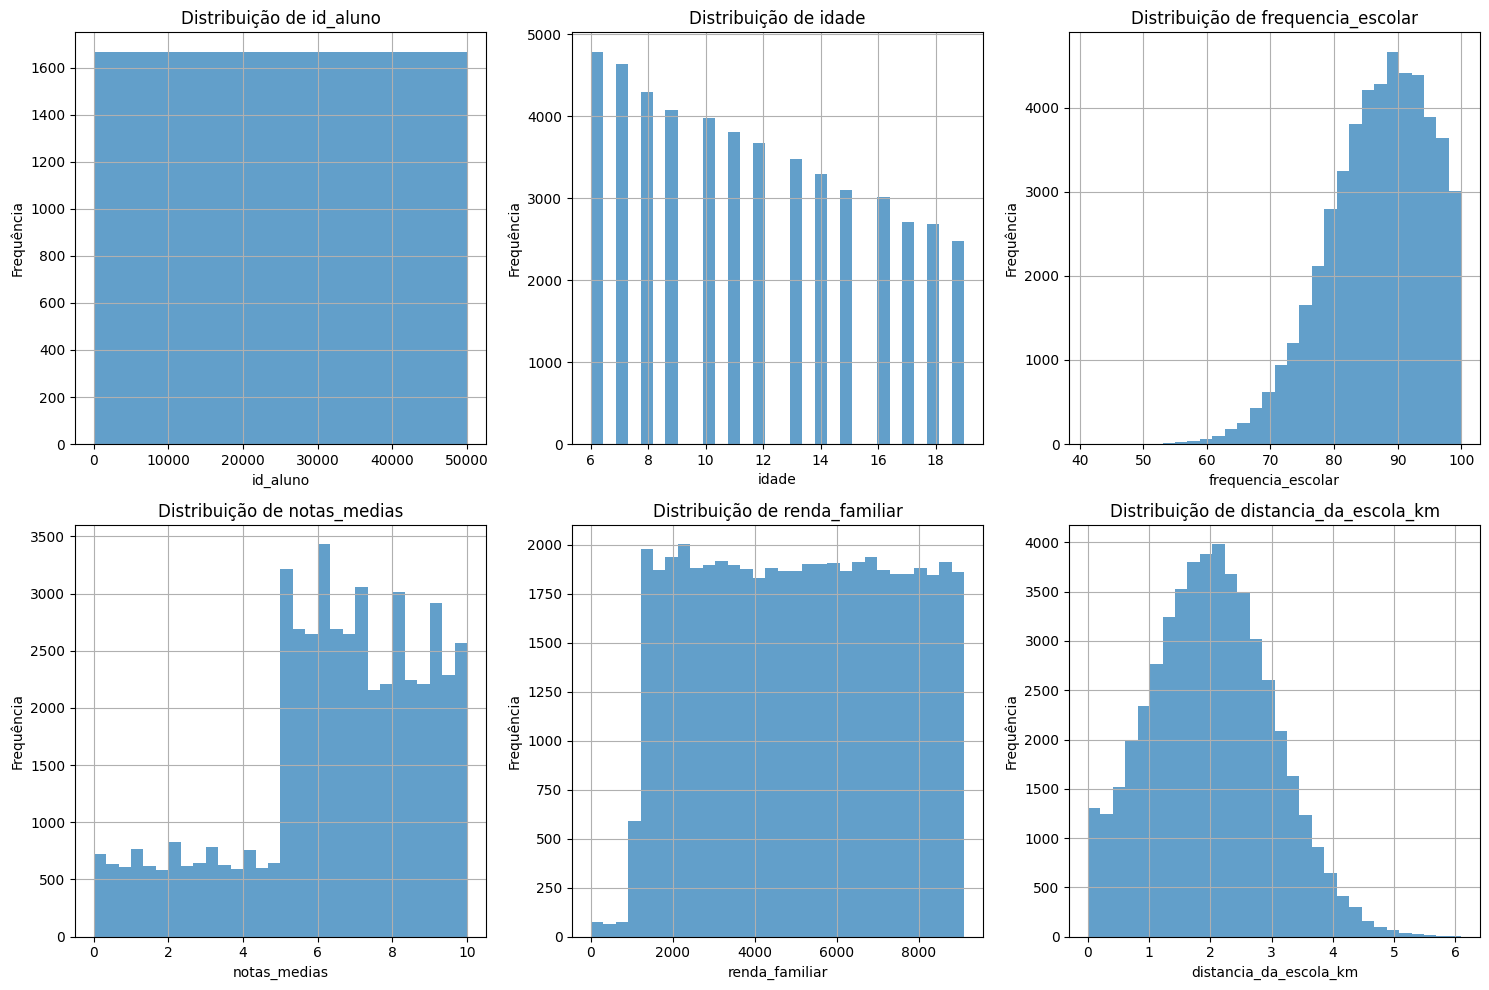

========== Var. Categóricas ==========


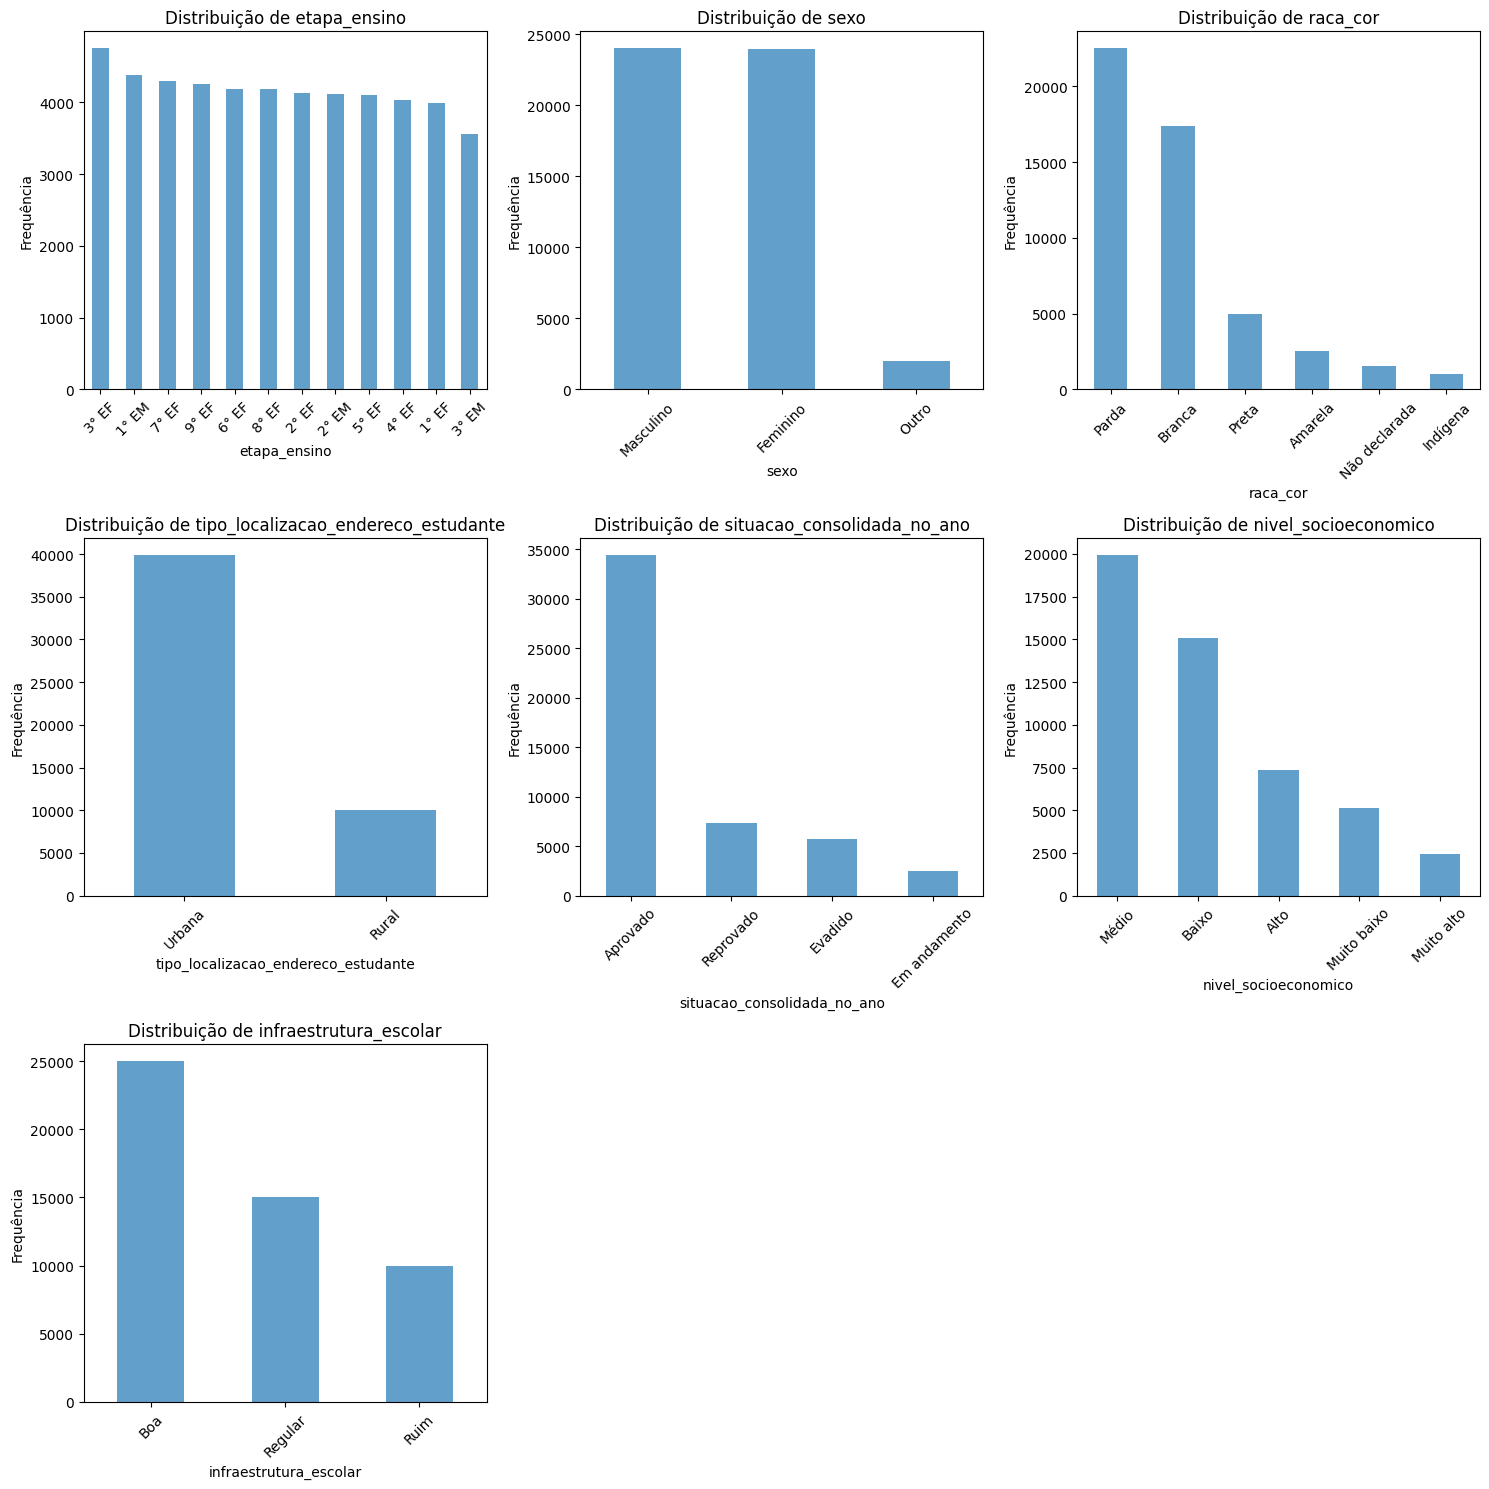

In [4]:
import matplotlib.pyplot as plt

def plot_numerical_distributions(df):
    numerical_cols = df.select_dtypes(include=[np.number]).columns
    n_cols = len(numerical_cols)
    n_rows = (n_cols + 2) // 3  # 3 colunas por linha
    
    fig, axes = plt.subplots(n_rows, 3, figsize=(15, 5*n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes]
    
    for i, col in enumerate(numerical_cols):
        df[col].hist(bins=30, ax=axes[i], alpha=0.7)
        axes[i].set_title(f'Distribuição de {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequência')
    
    # Remover subplots vazios
    for i in range(len(numerical_cols), len(axes)):
        fig.delaxes(axes[i])
    
    plt.tight_layout()
    plt.show()

# Para variáveis categóricas (gráficos de barras)
def plot_categorical_distributions(df):
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns
    n_cols = len(categorical_cols)
    n_rows = (n_cols + 2) // 3
    
    fig, axes = plt.subplots(n_rows, 3, figsize=(15, 5*n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes]
    
    for i, col in enumerate(categorical_cols):
        df[col].value_counts().plot(kind='bar', ax=axes[i], alpha=0.7)
        axes[i].set_title(f'Distribuição de {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequência')
        axes[i].tick_params(axis='x', rotation=45)
    
    for i in range(len(categorical_cols), len(axes)):
        fig.delaxes(axes[i])
    
    plt.tight_layout()
    plt.show()

# Uso
plot_numerical_distributions(df)
print("="*10 + " Var. Categóricas " + "="*10)
plot_categorical_distributions(df)

Dataset V5 carregado: 50000 linhas e 23 colunas.
Convertendo colunas categóricas para numéricas: ['etapa_ensino', 'sexo', 'raca_cor', 'tipo_localizacao_endereco_estudante', 'situacao_consolidada_no_ano', 'nivel_socioeconomico', 'infraestrutura_escolar']


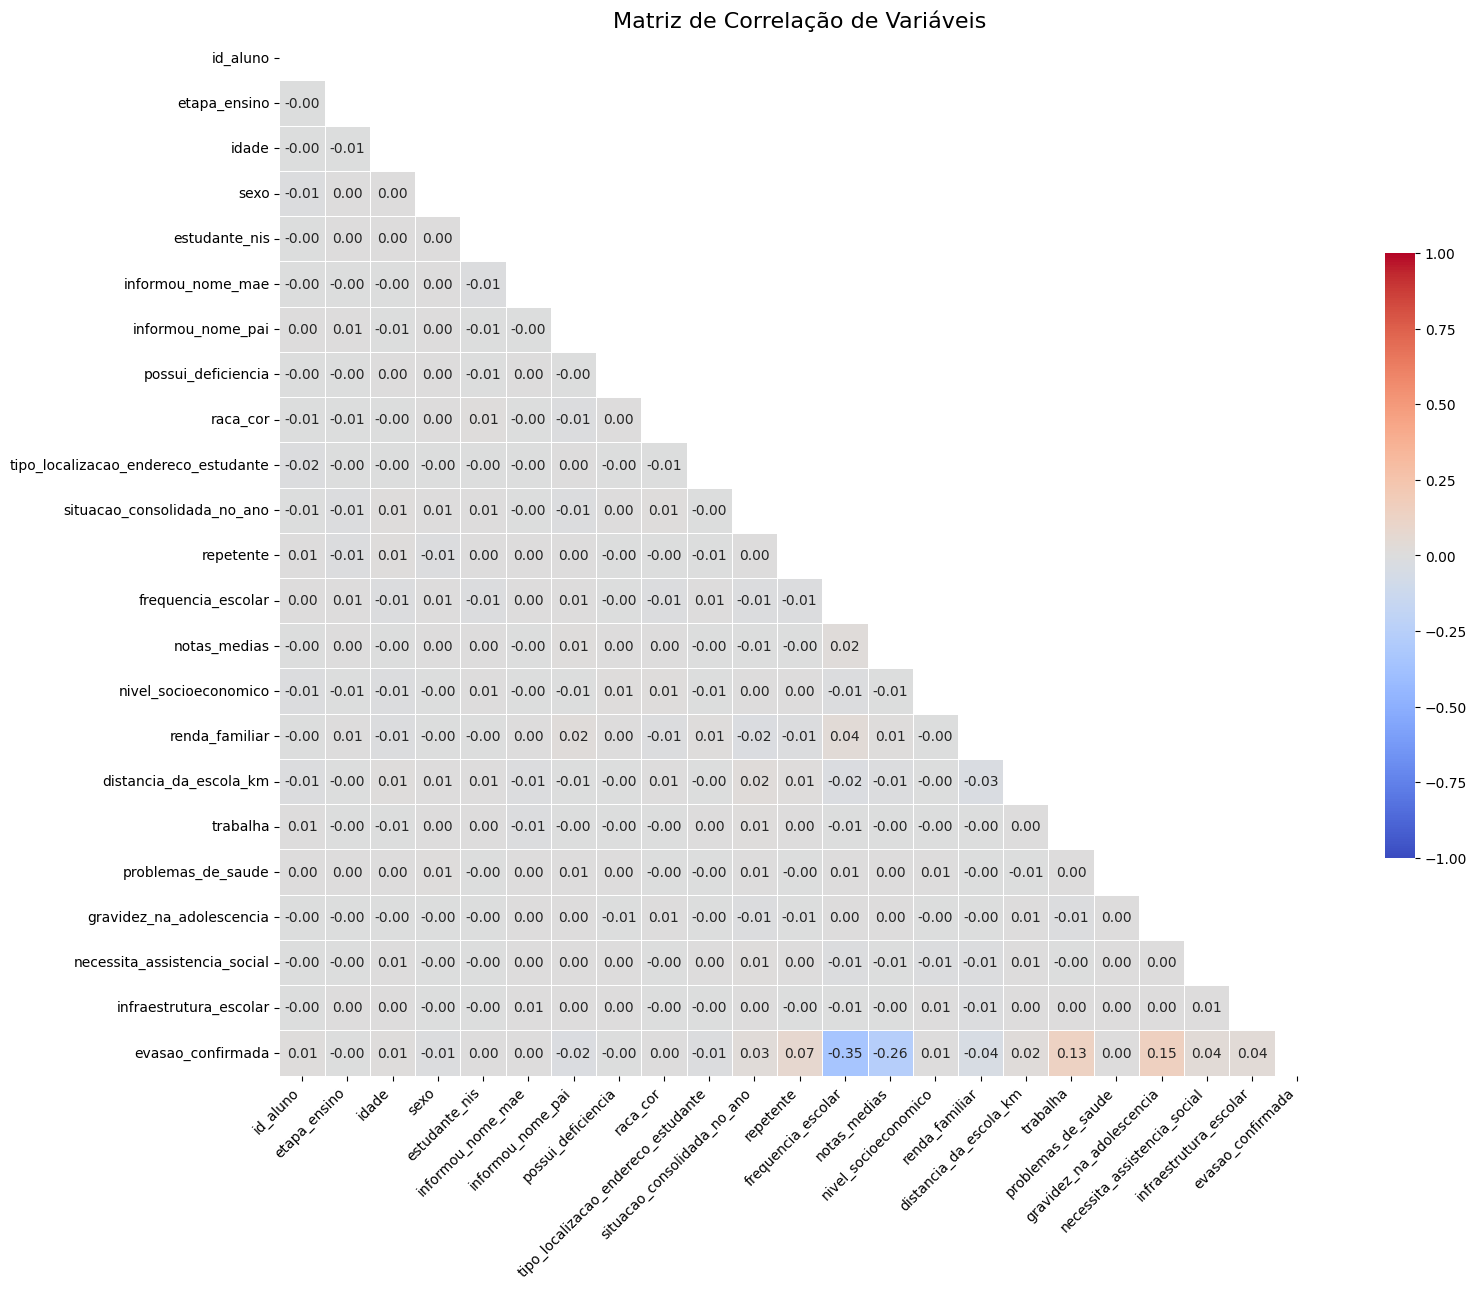


=== Fatores que mais influenciam a Evasão (Top Correlações) ===
frequencia_escolar              0.346373
notas_medias                    0.259865
gravidez_na_adolescencia        0.154075
trabalha                        0.133359
repetente                       0.073833
renda_familiar                  0.041575
necessita_assistencia_social    0.038489
infraestrutura_escolar          0.035264
situacao_consolidada_no_ano     0.026405
distancia_da_escola_km          0.023247
Name: evasao_confirmada, dtype: float64


In [9]:
# Heatmap

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

try:
    df = pd.read_csv("./dataset_evasao_sintetico_v6.csv")
    print(f"Dataset V5 carregado: {df.shape[0]} linhas e {df.shape[1]} colunas.")
except FileNotFoundError:
    print("Erro: Arquivo 'dataset_evasao_sintetico_v6.csv' não encontrado.")
    df = pd.DataFrame()

if not df.empty:
    df_viz = df.copy()
    
    # Identifica colunas de texto
    colunas_texto = df_viz.select_dtypes(include=['object']).columns
    
    print(f"Convertendo colunas categóricas para numéricas: {list(colunas_texto)}")
    
    for col in colunas_texto:
        df_viz[col] = df_viz[col].astype('category').cat.codes

    corr_matrix = df_viz.corr()

    plt.figure(figsize=(16, 14))
    
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

    # Desenha o Heatmap
    sns.heatmap(
        corr_matrix, 
        mask=mask,
        annot=True,         # Mostra os números nos quadrados
        fmt=".2f",          # Formatação (2 casas decimais)
        cmap='coolwarm',    # Azul (negativo) -> Vermelho (positivo)
        vmax=1, vmin=-1, center=0,
        square=True, 
        linewidths=.5, 
        cbar_kws={"shrink": .5}
    )

    plt.title("Matriz de Correlação de Variáveis", fontsize=16)
    plt.xticks(rotation=45, ha='right') 
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    print("\n=== Fatores que mais influenciam a Evasão (Top Correlações) ===")
    correlacao_evasao = corr_matrix['evasao_confirmada'].drop('evasao_confirmada')
    print(correlacao_evasao.abs().sort_values(ascending=False).head(10))